In [2]:
import pandas as pd
import numpy as np
from datetime import timedelta, date

# Generate dates for the last 3 summers in Jaipur
start_date = date(2023, 4, 1)
end_date = date(2026, 6, 27)
dates = pd.date_range(start_date, end_date, freq='D')

# Create realistic Jaipur summer temperatures (Hotter in May/June)
np.random.seed(42)
temperatures = 35 + 10 * np.sin(np.pi * dates.month / 6) + np.random.normal(0, 2, len(dates))

# Create Power Grid Load (spikes when temp goes above 40°C)
base_load = 1500 # Megawatts
power_load = base_load + (temperatures - 30) * 50 + np.random.normal(0, 50, len(dates))
power_load = np.where(temperatures > 42, power_load + 300, power_load) # AC usage spike

# Create the dataframe
df = pd.DataFrame({'Date': dates, 'Max_Temp_C': temperatures, 'Grid_Load_MW': power_load})

# Introduce some fake missing values to prove you know how to "clean" data
df.loc[df.sample(frac=0.05).index, 'Max_Temp_C'] = np.nan 

# Save to CSV
df.to_csv('jaipur_raw_energy_data.csv', index=False)
print("Raw dataset created successfully!")

Raw dataset created successfully!


Missing values BEFORE cleaning:
 Date             0
Max_Temp_C      59
Grid_Load_MW     0
dtype: int64

Missing values AFTER cleaning:
 Date            0
Max_Temp_C      0
Grid_Load_MW    0
dtype: int64

Clean data saved successfully as 'jaipur_cleaned_energy_data.csv'!


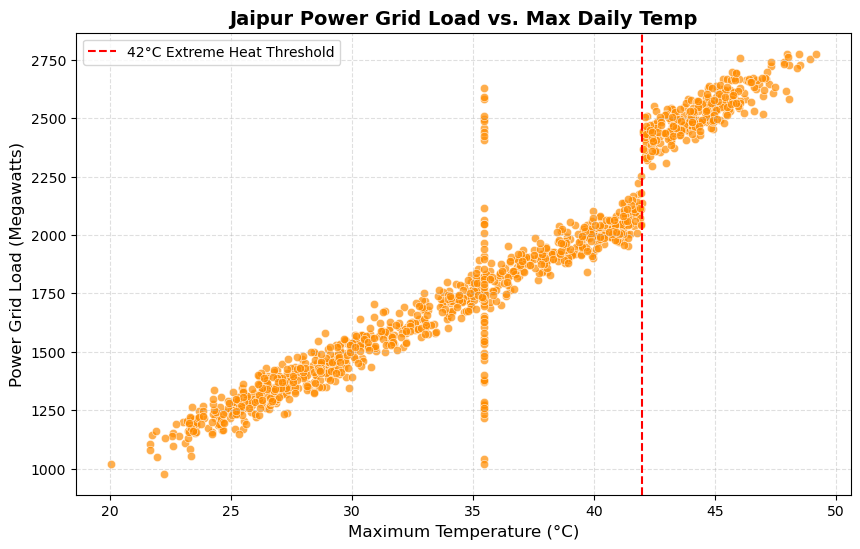

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the raw data you just created
df = pd.read_csv('jaipur_raw_energy_data.csv')
print("Missing values BEFORE cleaning:\n", df.isnull().sum())

# 2. Clean the data (Fill missing temperatures with the average)
mean_temp = df['Max_Temp_C'].mean()
df['Max_Temp_C'] = df['Max_Temp_C'].fillna(mean_temp).round(2)
df['Grid_Load_MW'] = df['Grid_Load_MW'].round(2)
print("\nMissing values AFTER cleaning:\n", df.isnull().sum())

# Save the cleaned data for our dashboard later
df.to_csv('jaipur_cleaned_energy_data.csv', index=False)
print("\nClean data saved successfully as 'jaipur_cleaned_energy_data.csv'!")

# 3. Create the Data Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Max_Temp_C', y='Grid_Load_MW', data=df, color='darkorange', alpha=0.7)

plt.title('Jaipur Power Grid Load vs. Max Daily Temp', fontsize=14, fontweight='bold')
plt.xlabel('Maximum Temperature (°C)', fontsize=12)
plt.ylabel('Power Grid Load (Megawatts)', fontsize=12)

# Draw a red line at 42°C to show the AC usage spike
plt.axvline(x=42, color='red', linestyle='--', label='42°C Extreme Heat Threshold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()